In [9]:
import pandas as pd
import os
from utils import get_run_group_dfs_sa
import matplotlib.pyplot as plt
import numpy as np

In [2]:
all_df = pd.read_csv('metrics/SA_Queens_GridSearch/learning_curve.csv')
run_df, group_df = get_run_group_dfs_sa(all_df)

/Users/sdale/repos/personal/machine_learning/randomized_optimization/utils.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  run_df.drop_duplicates(inplace=True)
/Users/sdale/repos/personal/machine_learning/randomized_optimization/utils.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  run_df.loc[mask, f"{key}_mean"] = temp_df[key].mean()
/Users/sdale/repos/personal/machine_learning/randomized_optimization/utils.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

In [3]:
len(run_df), len(group_df)

(45, 9)

In [4]:
group_df.columns

Index(['group_number', 'problem_size', 'max_iterations', 'max_attempts',
       'start_temperature', 'decay_type', 'total_iterations_mean',
       'total_iterations_std', 'total_time_mean', 'total_time_std',
       'best_fitness_mean', 'best_fitness_std', 'total_fevals_mean',
       'total_fevals_std'],
      dtype='object')

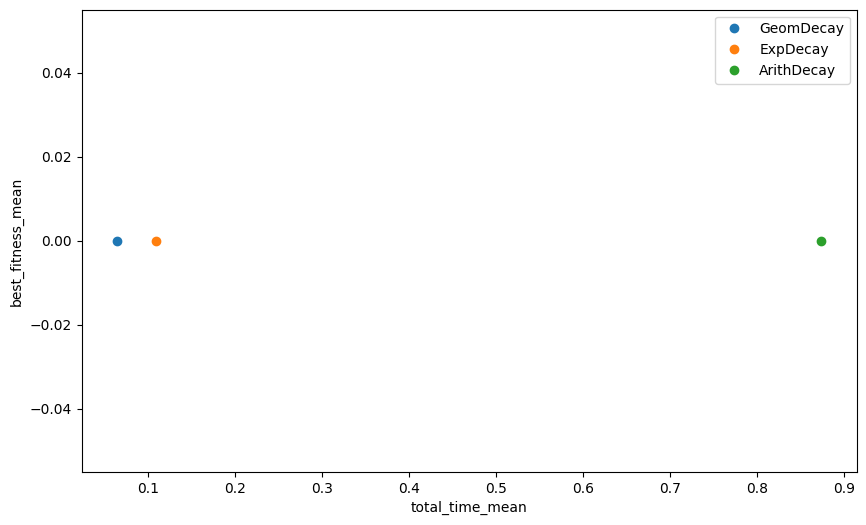

In [6]:
s_df = group_df[group_df['start_temperature'] == 1]
# plot the best_fitness_mean vs. total_time_mean for each decay_type
plt.figure(figsize=(10, 6))
plt.plot(s_df[s_df['decay_type'] == 'GeomDecay']['total_time_mean'], s_df[s_df['decay_type'] == 'GeomDecay']['best_fitness_mean'], 'o', label='GeomDecay')
plt.plot(s_df[s_df['decay_type'] == 'ExpDecay']['total_time_mean'], s_df[s_df['decay_type'] == 'ExpDecay']['best_fitness_mean'], 'o', label='ExpDecay')
plt.plot(s_df[s_df['decay_type'] == 'ArithDecay']['total_time_mean'], s_df[s_df['decay_type'] == 'ArithDecay']['best_fitness_mean'], 'o', label='ArithDecay')
plt.xlabel('total_time_mean')
plt.ylabel('best_fitness_mean')
plt.legend()

In [17]:
s_df = group_df[group_df['start_temperature'] == 1]

geom_decay_time_mean = s_df[s_df['decay_type'] == 'GeomDecay']['total_time_mean'].values[0]
assert(len(s_df[s_df['decay_type'] == 'GeomDecay']['total_time_mean'].values) == 1)
geom_decay_time_std = s_df[s_df['decay_type'] == 'GeomDecay']['total_time_std'].values[0]

exp_decay_time_mean = s_df[s_df['decay_type'] == 'ExpDecay']['total_time_mean'].values[0]
assert(len(s_df[s_df['decay_type'] == 'ExpDecay']['total_time_mean'].values) == 1)
exp_decay_time_std = s_df[s_df['decay_type'] == 'ExpDecay']['total_time_std'].values[0]

arith_decay_time_mean = s_df[s_df['decay_type'] == 'ArithDecay']['total_time_mean'].values[0]
assert(len(s_df[s_df['decay_type'] == 'ArithDecay']['total_time_mean'].values) == 1)
arith_decay_time_std = s_df[s_df['decay_type'] == 'ArithDecay']['total_time_std'].values[0]

In [18]:
# Create lists for the plot
decay_types = ['GeomDecay', 'ExpDecay', 'ArithDecay']
x_pos = np.arange(len(decay_types))
means = [geom_decay_time_mean, exp_decay_time_mean, arith_decay_time_mean]
stds = [geom_decay_time_std, exp_decay_time_std, arith_decay_time_std]

In [19]:
stds

[0.03779282986488059, 0.04791392669553798, 0.7165625351866326]

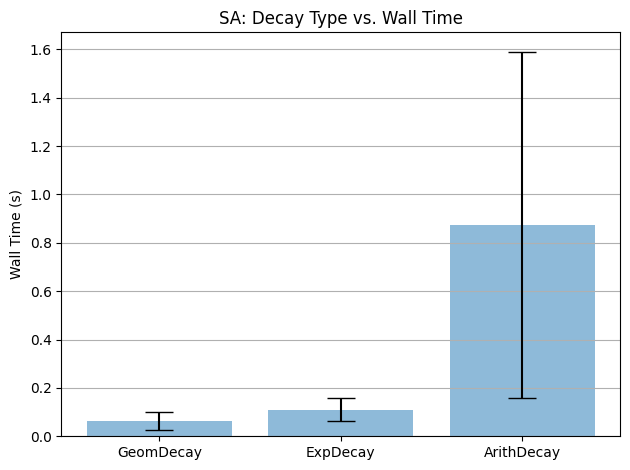

In [20]:

# Build the plot
fig, ax = plt.subplots()
ax.bar(x_pos, means, yerr=stds, align='center', alpha=0.5, ecolor='black', capsize=10)
ax.set_ylabel('Wall Time (s)')
ax.set_xticks(x_pos)
ax.set_xticklabels(decay_types)
ax.set_title('Simulated Annealing: Decay Type vs. Wall Time')
ax.yaxis.grid(True)

# Save the figure and show
plt.tight_layout()
plt.savefig('results/sa_decay_type_vs_wall_time.png')
plt.show()